In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)


In [11]:

SHANNON_RADII = {
    
    ('Li',1,12):1.36, ('Li',1,6):0.76,
    ('Na',1,12):1.39, ('Na',1,6):1.02,
    ('K', 1,12):1.64, ('K', 1,6):1.38,
    ('Rb',1,12):1.72, ('Rb',1,6):1.52,
    ('Cs',1,12):1.88, ('Cs',1,6):1.67,
    ('Ag',1,12):1.28, ('Ag',1,6):1.15,
    ('Tl',1,12):1.70, ('Tl',1,6):1.50,
    ('Ca',2,12):1.34, ('Ca',2,6):1.00,
    ('Sr',2,12):1.44, ('Sr',2,6):1.18,
    ('Ba',2,12):1.61, ('Ba',2,6):1.35,
    ('Pb',2,12):1.49, ('Pb',2,6):1.19,
    ('Sn',2,12):1.35, ('Sn',2,6):1.18,
    ('Eu',2,12):1.35, ('Eu',2,6):1.17,
    ('Sm',2,12):1.36, ('Sm',2,6):1.22,
    ('Yb',2,12):1.16, ('Yb',2,6):1.02,
    ('Mn',2,12):1.27, ('Mn',2,6):0.83,
    ('Fe',2,12):1.21, ('Fe',2,6):0.78,
    ('Co',2,12):1.19, ('Co',2,6):0.745,
    ('Ni',2,12):1.12, ('Ni',2,6):0.69,
    ('Cd',2,12):1.31, ('Cd',2,6):0.95,
    ('Ge',2,12):1.13, ('Ge',2,6):0.73,
    ('La',3,12):1.36, ('La',3,6):1.032,
    ('Ce',3,12):1.34, ('Ce',3,6):1.01,
    ('Pr',3,12):1.30, ('Pr',3,6):0.99,
    ('Nd',3,12):1.27, ('Nd',3,6):0.983,
    ('Sm',3,12):1.24, ('Sm',3,6):0.958,
    ('Eu',3,12):1.23, ('Eu',3,6):0.947,
    ('Gd',3,12):1.22, ('Gd',3,6):0.938,
    ('Tb',3,12):1.20, ('Tb',3,6):0.923,
    ('Dy',3,12):1.19, ('Dy',3,6):0.912,
    ('Ho',3,12):1.18, ('Ho',3,6):0.901,
    ('Er',3,12):1.17, ('Er',3,6):0.890,
    ('Tm',3,12):1.16, ('Tm',3,6):0.880,
    ('Yb',3,12):1.16, ('Yb',3,6):0.868,
    ('Lu',3,12):1.15, ('Lu',3,6):0.861,
    ('Y', 3,12):1.20, ('Y', 3,6):0.90,
    ('Bi',3,12):1.45, ('Bi',3,6):1.03,
    ('In',3,12):1.32, ('In',3,6):0.80,
    ('Tl',3,12):1.12, ('Tl',3,6):0.885,
    ('Fe',3,12):1.09, ('Fe',3,6):0.645,
    ('Cr',3,12):1.09, ('Cr',3,6):0.615,
    ('Ga',3,12):1.07, ('Ga',3,6):0.62,
    ('Al',3,12):1.08, ('Al',3,6):0.535,
    ('Sc',3,12):1.16, ('Sc',3,6):0.745,
    ('V', 3,12):1.04, ('V', 3,6):0.64,
    ('Mn',3,12):1.04, ('Mn',3,6):0.645,
    ('Co',3,12):1.06, ('Co',3,6):0.61,
    ('Rh',3,12):1.07, ('Rh',3,6):0.665,
    ('Ce',4,12):1.14, ('Ce',4,6):0.87,
    ('Zr',4,12):1.16, ('Zr',4,6):0.72,
    ('Hf',4,12):1.12, ('Hf',4,6):0.71,
    ('Ti',4,12):1.02, ('Ti',4,6):0.605,
    ('Sn',4,12):1.12, ('Sn',4,6):0.69,
    ('Pb',4,12):1.14, ('Pb',4,6):0.775,
    ('Mn',4,12):1.00, ('Mn',4,6):0.53,
    ('Ge',4,12):0.87, ('Ge',4,6):0.53,
    ('Si',4,12):0.84, ('Si',4,6):0.40,
    ('V', 4,12):1.00, ('V', 4,6):0.58,
    ('Mo',4,12):1.06, ('Mo',4,6):0.65,
    ('W', 4,12):1.06, ('W', 4,6):0.66,
    ('Nb',5,12):1.04, ('Nb',5,6):0.64,
    ('Ta',5,12):1.04, ('Ta',5,6):0.64,
    ('V', 5,12):0.99, ('V', 5,6):0.54,
    
    ('Be',2,6):0.45, ('Mg',2,6):0.72, ('Zn',2,6):0.74,
    ('Cu',2,6):0.73, ('Pd',2,6):0.86,
    
    ('O', -2,6):1.40,
    ('F', -1,6):1.33,
    ('Cl',-1,6):1.81,
    ('Br',-1,6):1.96,
    ('I', -1,6):2.20,
}

def get_radius(ion, ox_state, cn, fallback_cn=6):
    
    r = SHANNON_RADII.get((ion, ox_state, cn))
    if r is None:
        r = SHANNON_RADII.get((ion, ox_state, fallback_cn))
    return r



In [12]:
RAW_DATA = [
    
    ('La',3,'Al',3,'O',-2,1), ('La',3,'Ga',3,'O',-2,1), ('La',3,'Fe',3,'O',-2,1),
    ('La',3,'Cr',3,'O',-2,1), ('La',3,'Mn',3,'O',-2,1), ('La',3,'Co',3,'O',-2,1),
    ('La',3,'Ni',3,'O',-2,1), ('La',3,'V',3,'O',-2,1),  ('La',3,'Sc',3,'O',-2,1),
    ('La',3,'In',3,'O',-2,1), ('La',3,'Rh',3,'O',-2,1),
    ('Nd',3,'Al',3,'O',-2,1), ('Nd',3,'Fe',3,'O',-2,1), ('Nd',3,'Cr',3,'O',-2,1),
    ('Nd',3,'Mn',3,'O',-2,1), ('Nd',3,'Co',3,'O',-2,1), ('Nd',3,'Sc',3,'O',-2,1),
    ('Sm',3,'Al',3,'O',-2,1), ('Sm',3,'Fe',3,'O',-2,1), ('Sm',3,'Cr',3,'O',-2,1),
    ('Sm',3,'Mn',3,'O',-2,1), ('Sm',3,'Co',3,'O',-2,1), ('Sm',3,'Sc',3,'O',-2,1),
    ('Gd',3,'Al',3,'O',-2,1), ('Gd',3,'Fe',3,'O',-2,1), ('Gd',3,'Cr',3,'O',-2,1),
    ('Gd',3,'Mn',3,'O',-2,1), ('Gd',3,'Co',3,'O',-2,1), ('Gd',3,'Sc',3,'O',-2,1),
    ('Dy',3,'Al',3,'O',-2,1), ('Dy',3,'Fe',3,'O',-2,1), ('Dy',3,'Sc',3,'O',-2,1),
    ('Y', 3,'Al',3,'O',-2,1), ('Y', 3,'Fe',3,'O',-2,1), ('Y', 3,'Cr',3,'O',-2,1),
    ('Y', 3,'Mn',3,'O',-2,1), ('Y', 3,'Sc',3,'O',-2,1), ('Y', 3,'In',3,'O',-2,1),
    ('Lu',3,'Al',3,'O',-2,1), ('Lu',3,'Fe',3,'O',-2,1), ('Lu',3,'Cr',3,'O',-2,1),
    ('Lu',3,'Sc',3,'O',-2,1),
    ('Bi',3,'Fe',3,'O',-2,1), ('Bi',3,'Cr',3,'O',-2,1),
    
    ('In',3,'Fe',3,'O',-2,0), ('In',3,'Cr',3,'O',-2,0), ('In',3,'Mn',3,'O',-2,0),
    ('Sc',3,'Fe',3,'O',-2,0), ('Sc',3,'Cr',3,'O',-2,0), ('Sc',3,'Mn',3,'O',-2,0),
    ('Al',3,'Fe',3,'O',-2,0), ('Ga',3,'Fe',3,'O',-2,0), ('Ga',3,'Cr',3,'O',-2,0),
    
    ('Ba',2,'Ti',4,'O',-2,1), ('Ba',2,'Zr',4,'O',-2,1), ('Ba',2,'Hf',4,'O',-2,1),
    ('Ba',2,'Sn',4,'O',-2,1), ('Ba',2,'Ce',4,'O',-2,1),
    ('Sr',2,'Ti',4,'O',-2,1), ('Sr',2,'Zr',4,'O',-2,1), ('Sr',2,'Hf',4,'O',-2,1),
    ('Sr',2,'Sn',4,'O',-2,1), ('Sr',2,'Ce',4,'O',-2,1),
    ('Ca',2,'Ti',4,'O',-2,1), ('Ca',2,'Zr',4,'O',-2,1), ('Ca',2,'Hf',4,'O',-2,1),
    ('Ca',2,'Sn',4,'O',-2,1), ('Ca',2,'Ce',4,'O',-2,1),
    ('Pb',2,'Ti',4,'O',-2,1), ('Pb',2,'Zr',4,'O',-2,1), ('Pb',2,'Hf',4,'O',-2,1),
    ('Cd',2,'Ti',4,'O',-2,1), ('Cd',2,'Zr',4,'O',-2,1),
    ('Mn',2,'Ti',4,'O',-2,1),
    
    ('Fe',2,'Ti',4,'O',-2,0), ('Ni',2,'Ti',4,'O',-2,0), ('Co',2,'Ti',4,'O',-2,0),
    ('Zn',2,'Ti',4,'O',-2,0), ('Mg',2,'Ti',4,'O',-2,0),
    ('Mg',2,'Si',4,'O',-2,0), ('Fe',2,'Si',4,'O',-2,0), ('Ca',2,'Si',4,'O',-2,0),
    
    ('Na',1,'Nb',5,'O',-2,1), ('Na',1,'Ta',5,'O',-2,1),
    ('K', 1,'Nb',5,'O',-2,1), ('K', 1,'Ta',5,'O',-2,1),
    ('Rb',1,'Nb',5,'O',-2,1), ('Rb',1,'Ta',5,'O',-2,1),
    ('Li',1,'Nb',5,'O',-2,1), ('Li',1,'Ta',5,'O',-2,1),
    ('Ag',1,'Nb',5,'O',-2,1),
    ('Na',1,'V', 5,'O',-2,0),
    
    ('K', 1,'Mg',2,'F',-1,1), ('K', 1,'Zn',2,'F',-1,1), ('K', 1,'Mn',2,'F',-1,1),
    ('K', 1,'Fe',2,'F',-1,1), ('K', 1,'Co',2,'F',-1,1), ('K', 1,'Ni',2,'F',-1,1),
    ('K', 1,'Cu',2,'F',-1,1), ('K', 1,'Cd',2,'F',-1,1),
    ('Rb',1,'Mg',2,'F',-1,1), ('Rb',1,'Zn',2,'F',-1,1), ('Rb',1,'Mn',2,'F',-1,1),
    ('Rb',1,'Fe',2,'F',-1,1), ('Rb',1,'Co',2,'F',-1,1), ('Rb',1,'Ni',2,'F',-1,1),
    ('Cs',1,'Mg',2,'F',-1,1), ('Cs',1,'Zn',2,'F',-1,1), ('Cs',1,'Mn',2,'F',-1,1),
    ('Cs',1,'Fe',2,'F',-1,1), ('Cs',1,'Co',2,'F',-1,1), ('Cs',1,'Ni',2,'F',-1,1),
    ('Na',1,'Mn',2,'F',-1,1), ('Na',1,'Fe',2,'F',-1,1), ('Na',1,'Co',2,'F',-1,1),
    ('Na',1,'Ni',2,'F',-1,1), ('Na',1,'Zn',2,'F',-1,1),
    ('Tl',1,'Mg',2,'F',-1,1), ('Tl',1,'Mn',2,'F',-1,1), ('Tl',1,'Fe',2,'F',-1,1),
    
    ('Na',1,'Be',2,'F',-1,0), ('K', 1,'Be',2,'F',-1,0), ('Li',1,'Mg',2,'F',-1,0),
    
    ('K', 1,'Al',3,'F',-1,1), ('K', 1,'Ga',3,'F',-1,1), ('K', 1,'In',3,'F',-1,1),
    ('K', 1,'Fe',3,'F',-1,1), ('K', 1,'Cr',3,'F',-1,1), ('K', 1,'Sc',3,'F',-1,1),
    ('Rb',1,'Al',3,'F',-1,1), ('Rb',1,'Ga',3,'F',-1,1), ('Rb',1,'In',3,'F',-1,1),
    ('Rb',1,'Fe',3,'F',-1,1), ('Rb',1,'Cr',3,'F',-1,1), ('Rb',1,'Sc',3,'F',-1,1),
    ('Cs',1,'Al',3,'F',-1,1), ('Cs',1,'Ga',3,'F',-1,1), ('Cs',1,'In',3,'F',-1,1),
    ('Cs',1,'Fe',3,'F',-1,1), ('Cs',1,'Cr',3,'F',-1,1), ('Cs',1,'Sc',3,'F',-1,1),
    ('Na',1,'Al',3,'F',-1,1), ('Na',1,'Fe',3,'F',-1,1), ('Na',1,'Cr',3,'F',-1,1),
    ('Na',1,'Sc',3,'F',-1,1),
    
    ('Li',1,'Al',3,'F',-1,0), ('Li',1,'Fe',3,'F',-1,0), ('Li',1,'Cr',3,'F',-1,0),
    ('Li',1,'V', 3,'F',-1,0), ('Li',1,'In',3,'F',-1,0), ('Li',1,'Sc',3,'F',-1,0),
    
    ('Cs',1,'Ca',2,'Cl',-1,1), ('Cs',1,'Mn',2,'Cl',-1,1), ('Cs',1,'Co',2,'Cl',-1,1),
    ('Cs',1,'Cd',2,'Cl',-1,1), ('Cs',1,'In',3,'Cl',-1,1), ('Cs',1,'Tl',3,'Cl',-1,1),
    ('Rb',1,'Mn',2,'Cl',-1,1),
   
    ('Cs',1,'Be',2,'Cl',-1,0), ('Cs',1,'Mg',2,'Cl',-1,0), ('Cs',1,'Zn',2,'Cl',-1,0),
    ('Cs',1,'Fe',2,'Cl',-1,0), ('Cs',1,'Ni',2,'Cl',-1,0), ('Cs',1,'Hg',2,'Cl',-1,0),
    ('Rb',1,'Fe',2,'Cl',-1,0), ('Rb',1,'Co',2,'Cl',-1,0), ('Rb',1,'Cd',2,'Cl',-1,0),
    ('K', 1,'Mn',2,'Cl',-1,0), ('K', 1,'Fe',2,'Cl',-1,0), ('K', 1,'Cd',2,'Cl',-1,0),
    ('Na',1,'Mn',2,'Cl',-1,0), ('Li',1,'Mg',2,'Cl',-1,0),
    
    ('Cs',1,'Ge',2,'Br',-1,1), ('Cs',1,'Sn',2,'Br',-1,1), ('Cs',1,'Pb',2,'Br',-1,1),
    ('Cs',1,'Mn',2,'Br',-1,1), ('Cs',1,'Cd',2,'Br',-1,1), ('Cs',1,'Co',2,'Br',-1,1),
    ('Cs',1,'Eu',2,'Br',-1,1), ('Cs',1,'In',3,'Br',-1,1), ('Cs',1,'Tl',3,'Br',-1,1),
    ('Rb',1,'Ge',2,'Br',-1,1), ('Rb',1,'Sn',2,'Br',-1,1), ('Rb',1,'Pb',2,'Br',-1,1),
    ('K', 1,'Ge',2,'Br',-1,1), ('K', 1,'Sn',2,'Br',-1,1), ('K', 1,'Pb',2,'Br',-1,1),
    
    ('Cs',1,'Be',2,'Br',-1,0), ('Cs',1,'Mg',2,'Br',-1,0), ('Cs',1,'Zn',2,'Br',-1,0),
    ('Cs',1,'Fe',2,'Br',-1,0), ('Cs',1,'Ni',2,'Br',-1,0), ('Cs',1,'Hg',2,'Br',-1,0),
    ('Rb',1,'Mn',2,'Br',-1,0), ('K', 1,'Mn',2,'Br',-1,0),
    
    ('Cs',1,'Ge',2,'I',-1,1),  ('Cs',1,'Sn',2,'I',-1,1), ('Cs',1,'Pb',2,'I',-1,1),
    ('Cs',1,'Eu',2,'I',-1,1),
    ('Rb',1,'Ge',2,'I',-1,1),  ('Rb',1,'Sn',2,'I',-1,1), ('Rb',1,'Pb',2,'I',-1,1),
    ('K', 1,'Ge',2,'I',-1,1),  ('K', 1,'Sn',2,'I',-1,1), ('K', 1,'Pb',2,'I',-1,1),
    
    ('Cs',1,'Be',2,'I',-1,0), ('Cs',1,'Mg',2,'I',-1,0), ('Cs',1,'Zn',2,'I',-1,0),
    ('Cs',1,'Ca',2,'I',-1,0), ('Cs',1,'Mn',2,'I',-1,0), ('Cs',1,'Fe',2,'I',-1,0),
    ('Rb',1,'Mn',2,'I',-1,0), ('K', 1,'Mn',2,'I',-1,0),
]

print(f'Total entries defined: {len(RAW_DATA)}')
perov = sum(1 for e in RAW_DATA if e[-1]==1)
print(f'Perovskites: {perov}, Non-perovskites: {len(RAW_DATA)-perov}')

Total entries defined: 213
Perovskites: 156, Non-perovskites: 57


In [13]:
def build_dataset(raw_data):
    records = []
    skipped = 0
    for entry in raw_data:
        A, nA, B, nB, X, nX, label = entry
        rA = get_radius(A, nA, 12, fallback_cn=6)
        rB = get_radius(B, nB, 6)
        rX = get_radius(X, nX, 6)
        if rA is None or rB is None or rX is None:
            skipped += 1
            continue
        
        t = (rA + rX) / (np.sqrt(2) * (rB + rX))
        
        ratio = rA / rB
        if ratio <= 0 or ratio == 1.0:
            skipped += 1
            continue
        tau = (rX / rB) - nA * (nA - ratio / np.log(ratio))
        records.append({
            'compound': f'{A}{B}{X}3',
            'A':A, 'nA':nA, 'B':B, 'nB':nB, 'X':X,
            'rA':rA, 'rB':rB, 'rX':rX,
            't':t, 'tau':tau, 'label':label, 'anion':X
        })
    print(f'Skipped {skipped} entries (missing radii)')
    return pd.DataFrame(records)

df = build_dataset(RAW_DATA)
print(f'Dataset: {len(df)} compounds')
print(f'Perovskites: {df["label"].sum()}, Non-perovskites: {(df["label"]==0).sum()}')
df[['compound','A','nA','B','nB','X','rA','rB','rX','t','tau','label']].head(10)

Skipped 3 entries (missing radii)
Dataset: 210 compounds
Perovskites: 155, Non-perovskites: 55


,compound,A,nA,B,nB,X,rA,rB,rX,t,tau,label
0,LaAlO3,La,3,Al,3,O,1.36,0.535,1.4,1.008586,1.790871,1
1,LaGaO3,La,3,Ga,3,O,1.36,0.620,1.4,0.966146,1.635497,1
2,LaFeO3,La,3,Fe,3,O,1.36,0.645,1.4,0.954335,1.649992,1
3,LaCrO3,La,3,Cr,3,O,1.36,0.615,1.4,0.968543,1.635796,1
4,LaMnO3,La,3,Mn,3,O,1.36,0.645,1.4,0.954335,1.649992,1
5,LaCoO3,La,3,Co,3,O,1.36,0.610,1.4,0.970953,1.637166,1
6,LaVO3,La,3,V,3,O,1.36,0.640,1.4,0.956674,1.644967,1
7,LaScO3,La,3,Sc,3,O,1.36,0.745,1.4,0.909844,1.978568,1
8,LaInO3,La,3,In,3,O,1.36,0.800,1.4,0.887098,2.361249,1
9,LaRhO3,La,3,Rh,3,O,1.36,0.665,1.4,0.945092,1.680724,1


In [14]:
# Apply decision boundaries
t_low, t_high  = 0.825, 1.059
tau_threshold  = 4.18

df['pred_t']   = ((df['t'] > t_low) & (df['t'] < t_high)).astype(int)
df['pred_tau'] = (df['tau'] < tau_threshold).astype(int)

acc_t   = accuracy_score(df['label'], df['pred_t'])
acc_tau = accuracy_score(df['label'], df['pred_tau'])

print(f'Goldschmidt (t) accuracy: {acc_t:.1%}  |  Paper reports: 74%')
print(f'Bartel (τ)     accuracy: {acc_tau:.1%}  |  Paper reports: 92%')
print(f'Improvement from τ:      +{(acc_tau-acc_t)*100:.1f} pp')
print()
print('Per-anion accuracy:')
print(f'{"Anion":5} {"n":5} {"Goldschmidt t":>15} {"Bartel τ":>12}')
print('-'*40)
for anion in ['O','F','Cl','Br','I']:
    sub = df[df['anion']==anion]
    if len(sub)==0: continue
    a_t   = accuracy_score(sub['label'], sub['pred_t'])
    a_tau = accuracy_score(sub['label'], sub['pred_tau'])
    print(f'{anion:5} {len(sub):5}    {a_t*100:>8.0f}%        {a_tau*100:>6.0f}%')

Goldschmidt (t) accuracy: 63.8%  |  Paper reports: 74%
Bartel (τ)     accuracy: 76.7%  |  Paper reports: 92%
Improvement from τ:      +12.9 pp

Per-anion accuracy:
Anion n       Goldschmidt t     Bartel τ
----------------------------------------
O        91          80%            87%
F        59          54%            83%
Cl       20          40%            65%
Br       22          64%            59%
I        18          39%            39%


In [15]:

tau_vals = df['tau'].values.reshape(-1,1)
labels   = df['label'].values

lr = LogisticRegression(random_state=42)
lr.fit(-tau_vals, labels)
df['P_tau'] = lr.predict_proba(-tau_vals)[:,1]

print('Logistic regression fitted for P(τ)')
print(f'Coefficient: {lr.coef_[0][0]:.4f}  |  Intercept: {lr.intercept_[0]:.4f}')
print()

examples = df[['compound','tau','P_tau','label']].sort_values('tau').iloc[::20]
print(examples.to_string(index=False))

Logistic regression fitted for P(τ)
Coefficient: 0.8218  |  Intercept: 4.1768

compound      tau    P_tau  label
  BiFeO3 1.495994 0.950143      1
  SmCrO3 1.902204 0.931734      1
  ScMnO3 2.363113 0.903337      0
  BaHfO3 3.511193 0.784382      1
  BaCeO3 3.622472 0.768514      1
  NaNiF3 3.803873 0.740941      1
  RbNbO3 3.905959 0.724516      1
 CsFeCl3 4.060271 0.698500      0
  LiAlF3 4.210664 0.671852      0
  KGeBr3 4.460513 0.625099      1
  FeSiO3 4.965660 0.524013      0


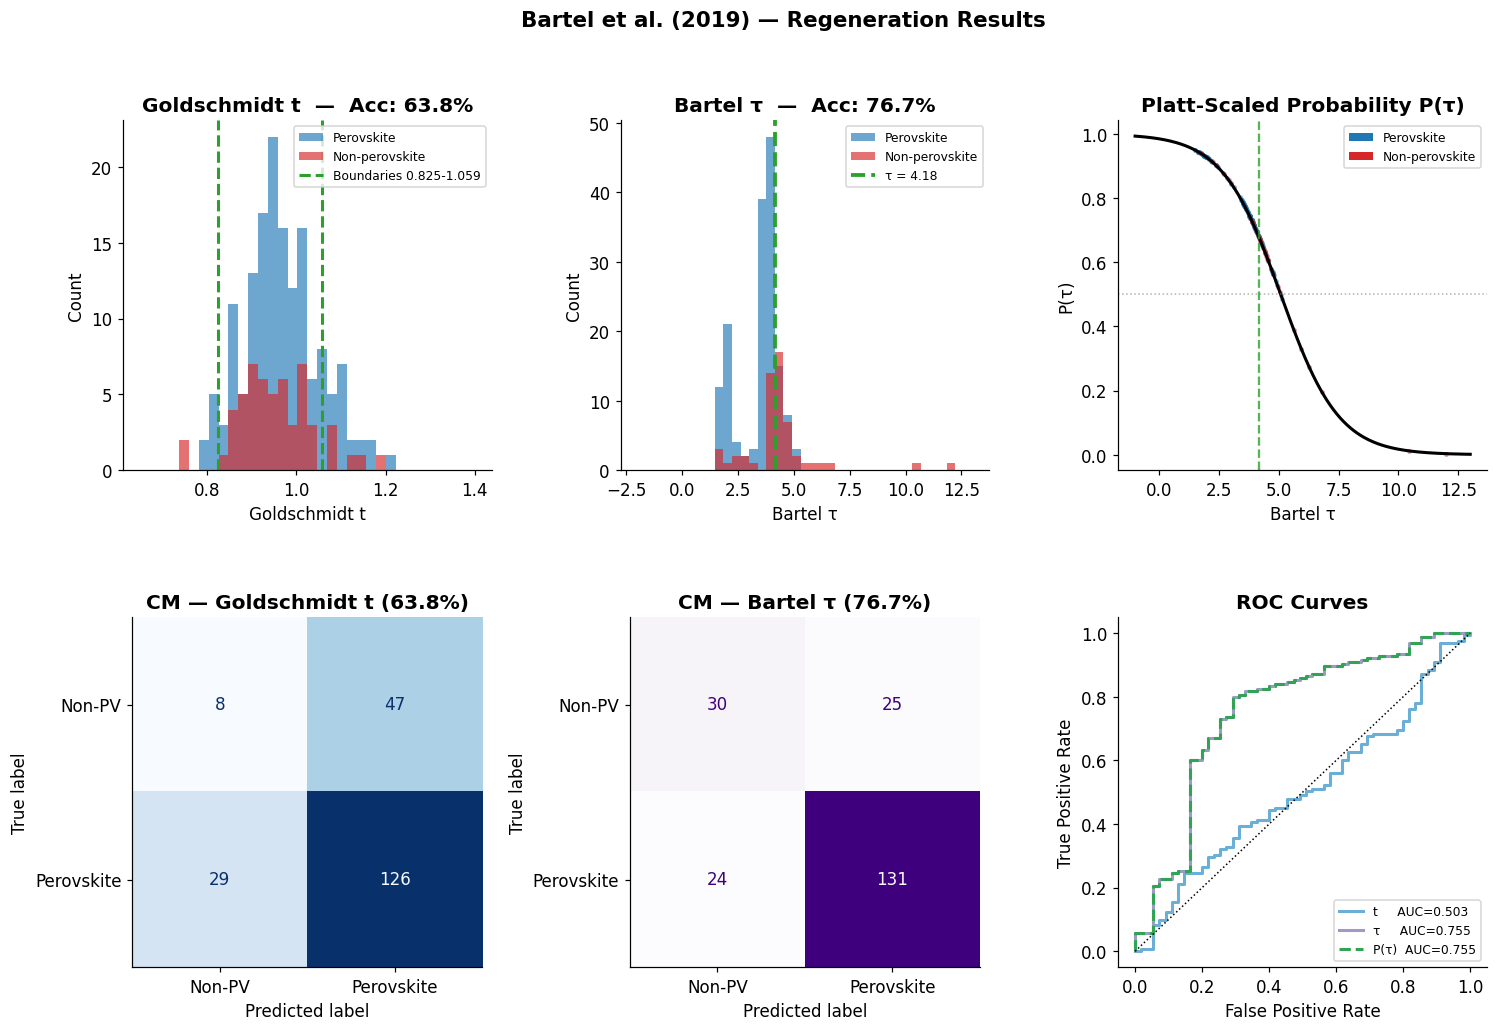

Figure saved as bartel_results.png


In [16]:
plt.rcParams.update({'font.size':11, 'figure.dpi':110,
                     'axes.spines.top':False, 'axes.spines.right':False})

COLORS = {
    'pv':  '#1f77b4',   
    'npv': '#d62728',   
    'bnd': '#2ca02c',   
    'O':'#e41a1c', 'F':'#377eb8', 'Cl':'#4daf4a', 'Br':'#ff7f00', 'I':'#984ea3'
}
MARKERS = {'O':'o','F':'s','Cl':'^','Br':'D','I':'v'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bartel et al. (2019) — Regeneration Results', fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.42, wspace=0.35)


ax = axes[0,0]
bins = np.linspace(0.65, 1.40, 35)
ax.hist(df[df['label']==1]['t'],  bins=bins, color=COLORS['pv'],  alpha=0.65, label='Perovskite')
ax.hist(df[df['label']==0]['t'],  bins=bins, color=COLORS['npv'], alpha=0.65, label='Non-perovskite')
ax.axvline(t_low,  color=COLORS['bnd'], lw=2, ls='--')
ax.axvline(t_high, color=COLORS['bnd'], lw=2, ls='--', label=f'Boundaries {t_low}-{t_high}')
ax.set_xlabel('Goldschmidt t'); ax.set_ylabel('Count')
ax.set_title(f'Goldschmidt t  —  Acc: {acc_t:.1%}', fontweight='bold')
ax.legend(fontsize=8)


ax = axes[0,1]
bins_tau = np.linspace(-2, 13, 40)
ax.hist(df[df['label']==1]['tau'], bins=bins_tau, color=COLORS['pv'],  alpha=0.65, label='Perovskite')
ax.hist(df[df['label']==0]['tau'], bins=bins_tau, color=COLORS['npv'], alpha=0.65, label='Non-perovskite')
ax.axvline(tau_threshold, color=COLORS['bnd'], lw=2.5, ls='--', label=f'τ = {tau_threshold}')
ax.set_xlabel('Bartel τ'); ax.set_ylabel('Count')
ax.set_title(f'Bartel τ  —  Acc: {acc_tau:.1%}', fontweight='bold')
ax.legend(fontsize=8)


ax = axes[0,2]
tau_range = np.linspace(-1, 13, 300)
p_line    = lr.predict_proba(-tau_range.reshape(-1,1))[:,1]
ax.plot(tau_range, p_line, 'k-', lw=2)
for _, row in df.iterrows():
    c = COLORS['pv'] if row['label']==1 else COLORS['npv']
    ax.scatter(row['tau'], row['P_tau'], c=c, s=10, alpha=0.5, linewidths=0)
ax.axvline(tau_threshold, color=COLORS['bnd'], lw=1.5, ls='--', alpha=0.8)
ax.axhline(0.5, color='gray', lw=1, ls=':', alpha=0.6)
ax.set_xlabel('Bartel τ'); ax.set_ylabel('P(τ)')
ax.set_title('Platt-Scaled Probability P(τ)', fontweight='bold')
legend_els = [Patch(fc=COLORS['pv'],label='Perovskite'),
              Patch(fc=COLORS['npv'],label='Non-perovskite')]
ax.legend(handles=legend_els, fontsize=8)


ax = axes[1,0]
cm_t = confusion_matrix(df['label'], df['pred_t'])
ConfusionMatrixDisplay(cm_t, display_labels=['Non-PV','Perovskite']).plot(ax=ax,colorbar=False,cmap='Blues')
ax.set_title(f'CM — Goldschmidt t ({acc_t:.1%})', fontweight='bold')

ax = axes[1,1]
cm_tau = confusion_matrix(df['label'], df['pred_tau'])
ConfusionMatrixDisplay(cm_tau, display_labels=['Non-PV','Perovskite']).plot(ax=ax,colorbar=False,cmap='Purples')
ax.set_title(f'CM — Bartel τ ({acc_tau:.1%})', fontweight='bold')


ax = axes[1,2]
t_center = (t_low + t_high) / 2
fpr_t,   tpr_t,   _ = roc_curve(df['label'], -np.abs(df['t'] - t_center))
fpr_tau, tpr_tau, _ = roc_curve(df['label'], -df['tau'])
fpr_p,   tpr_p,   _ = roc_curve(df['label'],  df['P_tau'])
auc_t   = roc_auc_score(df['label'], -np.abs(df['t'] - t_center))
auc_tau = roc_auc_score(df['label'], -df['tau'])
auc_p   = roc_auc_score(df['label'],  df['P_tau'])
ax.plot(fpr_t,   tpr_t,   '#6baed6', lw=2, label=f't     AUC={auc_t:.3f}')
ax.plot(fpr_tau, tpr_tau, '#9e9ac8', lw=2, label=f'τ     AUC={auc_tau:.3f}')
ax.plot(fpr_p,   tpr_p,   '#31a354', lw=2, ls='--', label=f'P(τ)  AUC={auc_p:.3f}')
ax.plot([0,1],[0,1],'k:',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

plt.savefig('bartel_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved as bartel_results.png')

In [17]:
tn_t,  fp_t,  fn_t,  tp_t  = confusion_matrix(df['label'], df['pred_t']).ravel()
tn_tau,fp_tau,fn_tau,tp_tau = confusion_matrix(df['label'], df['pred_tau']).ravel()

results = pd.DataFrame({
    'Metric': ['Overall Accuracy','True Positives','False Positives',
               'True Negatives','False Negatives',
               'Precision','Recall (TPR)','False Positive Rate','ROC-AUC'],
    'Goldschmidt t': [
        f'{acc_t:.1%}', tp_t, fp_t, tn_t, fn_t,
        f'{tp_t/(tp_t+fp_t):.1%}',
        f'{tp_t/(tp_t+fn_t):.1%}',
        f'{fp_t/(fp_t+tn_t):.1%}',
        f'{auc_t:.4f}'
    ],
    'Bartel τ': [
        f'{acc_tau:.1%}', tp_tau, fp_tau, tn_tau, fn_tau,
        f'{tp_tau/(tp_tau+fp_tau):.1%}',
        f'{tp_tau/(tp_tau+fn_tau):.1%}',
        f'{fp_tau/(fp_tau+tn_tau):.1%}',
        f'{auc_tau:.4f}'
    ],
    'Paper Reports': ['74% → 92%','','','','','','','51% → 11%','']
})
results

,Metric,Goldschmidt t,Bartel τ,Paper Reports
0,Overall Accuracy,63.8%,76.7%,74% → 92%
1,True Positives,126,131,
2,False Positives,47,25,
3,True Negatives,8,30,
4,False Negatives,29,24,
5,Precision,72.8%,84.0%,
6,Recall (TPR),81.3%,84.5%,
7,False Positive Rate,85.5%,45.5%,51% → 11%
8,ROC-AUC,0.5033,0.7551,
